In [2]:
#tools
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [3]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query arxiv papers")
print(arxiv.name)

arxiv


In [6]:
arxiv.invoke("SLIM style lingustic mismatched model")

'No good Wikipedia Search Result was found'

In [7]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [10]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [11]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/tmp/ipykernel_21599/1622265974.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [12]:
tavily.invoke("Provide me the recent work in deep fake audio detection")

[{'title': 'A systematic review of audio deepfake detection techniques for digital investigation | Discover Computing | Springer Nature Link',
  'url': 'https://link.springer.com/article/10.1007/s10791-026-10077-1',
  'content': 'To capture a comprehensive set of studies on audio deepfake detection, a well-defined search strategy was implemented. The search aimed to identify all relevant literature focusing on detection techniques, datasets, features, performance metrics, and evaluation methods. The search was conducted across multiple academic repositories, including IEEE Xplore, ACM Digital Library, Springer, MDPI, and other reputable sources. The search terms were formulated using Boolean operators to ensure inclusivity and precision. The primary keywords and phrases included as: (“audio deepfake detection” OR “audio forgery detection” OR “deepfake forensics” OR “fake audio detection”) AND (“existing studies” OR “literature review” OR “research”) AND (“techniques” OR “methods” OR “a

In [13]:
#combining all tool to integrate in LLM
tools=[arxiv,wiki,tavily]

In [16]:
#initialize the LLM Model
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")

In [17]:
llm.invoke("What is AI")

AIMessage(content="<think>\nOkay, the user is asking, What is AI? I need to give a clear and comprehensive answer while maintaining a natural tone. First, I should define artificial intelligence in simple terms. AI refers to machines or software that can perform tasks requiring human intelligence, like learning, reasoning, problem-solving, perception, and language understanding.\n\nNext, I can mention the main types of AI, such as Narrow AI (ANI), General AI (AGI), and Superintelligent AI (ASI), but focus more on ANI since it's the most common. I should explain the difference between weak and strong AI, but maybe avoid overly technical jargon to keep it accessible. Examples like voice assistants or recommendation systems can help illustrate the concepts.\n\nApplications of AI are important to highlight. Common areas include healthcare, finance, transportation, and entertainment. For instance, AI is used in medical diagnosis, fraud detection, autonomous vehicles, and personalized recomm

In [18]:
llm_with_tools=llm.bind_tools(tools=tools)

In [20]:
llm_with_tools.invoke("Recent research on deep fake ")


AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about recent research on deepfakes. Let me think about how to approach this.\n\nFirst, I need to understand what they mean by "recent." Since deepfake technology is evolving rapidly, the latest research might be from the past year or so. But I should check both Wikipedia and current search results to get the most up-to-date information.\n\nLooking at the tools available, there\'s a Wikipedia function and a Tavily search function. The Wikipedia tool is good for foundational knowledge and historical context, while Tavily can provide more recent studies and current events. \n\nI should start by using the Wikipedia function to get an overview of deepfake technology, its development, and existing research. Then, use Tavily to find the latest papers, advancements, or breakthroughs from the past year. \n\nWait, but maybe I should check Tavily first since the user is specifically asking for recent research.

In [21]:
llm_with_tools.invoke("WHat is machine learning")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is machine learning?" I need to provide a clear and concise explanation. Let me start by recalling the basics of machine learning. It\'s a subset of artificial intelligence that involves algorithms learning patterns from data. But I should make sure to define it properly.\n\nFirst, maybe I should use the Wikipedia function to get an accurate definition. The user might want a general overview, so using the wikipedia tool makes sense here. Let me check the tools available. There\'s a wikipedia function that takes a query. The query here would be "Machine learning".\n\nWait, there are two entries for Wikipedia in the tools. Maybe a duplication error, but the function name is the same. The parameters require a "query" string. So I\'ll use the wikipedia function with the query "Machine learning".\n\nI should also consider if the user needs more than just a definition. They might want examples or ap

## Workflow


In [22]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage  ## Human message or AI message
from typing import Annotated  ## labelling
from langgraph.graph.message import add_messages  ## Reducers in Langgraph

In [24]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [25]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [39]:
### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", END)

In [41]:
### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "tool_calling_llm")

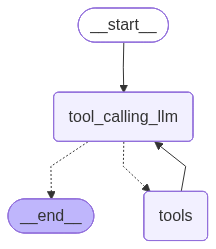

In [42]:
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
messages = graph.invoke({"messages": "Hi my name is prince and can you tell me the recent paper published in NEURIPS related with deepfake audio detection"})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is prince and can you tell me the recent paper published in NEURIPS related with deepfake audio detection
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (8k06zx2tv)
 Call ID: 8k06zx2tv
  Args:
    query: recent deepfake audio detection papers in NEURIPS
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "NeurIPS  MLADDC: Multi-Lingual Audio Deepfake Detection  Corpus", "url": "https://neurips.cc/virtual/2024/105760", "content": "cross-database method. For comparison, we also proposed baseline accuracy of 68.44 %, and EER of 40.9 % with MFCC features and CNN classifier (14 languages track only) indicating technological challenges associated with ADD task on proposed dataset. [...] This study develop Multi-Lingual Audio Deepfake Detection Corpus (ML